In [1]:
# 01 Data Understanding
#
# Purpose:
# This script performs the first raw-data inspection for the Telco Customer
# Churn classification project.
#
# At this stage, the goal is not to train models and not yet to perform full
# exploratory feature-target analysis. The goal is to inspect the raw dataset,
# identify obvious data-quality issues, and only make corrections when the raw
# inspection provides clear evidence.
#
# Important principle:
# - df_raw is kept unchanged.
# - If a correction is clearly justified, it is applied to df_inspect, not df_raw.
# - Every correction should be traceable to a raw-data finding.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.4f}".format)

In [4]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

TARGET_COLUMN = "Churn"
POSITIVE_CLASS = "Yes"
IDENTIFIER_COLUMN = "customerID"

# SeniorCitizen is stored as an integer in the raw data, but semantically it is
# a binary categorical feature: 0 = not senior citizen, 1 = senior citizen.
BINARY_CATEGORICAL_COLUMNS = ["SeniorCitizen"]

In [5]:
path_check = pd.DataFrame(
    {
        "item": [
            "current_working_directory",
            "project_root",
            "data_path",
            "data_path_exists",
        ],
        "value": [
            str(Path.cwd()),
            str(PROJECT_ROOT),
            str(DATA_PATH),
            DATA_PATH.exists(),
        ],
    }
)

path_check

,item,value
0,current_working_directory,C:\Projects_Data\classification\telco-customer...
1,project_root,C:\Projects_Data\classification\telco-customer...
2,data_path,C:\Projects_Data\classification\telco-customer...
3,data_path_exists,True


In [6]:
df_raw = pd.read_csv(DATA_PATH)

In [7]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [8]:
raw_overview = pd.DataFrame(
    {
        "item": [
            "number_of_rows",
            "number_of_columns",
            "duplicate_rows",
            "total_standard_missing_values",
            "columns_with_standard_missing_values",
        ],
        "value": [
            df_raw.shape[0],
            df_raw.shape[1],
            int(df_raw.duplicated().sum()),
            int(df_raw.isna().sum().sum()),
            int((df_raw.isna().sum() > 0).sum()),
        ],
    }
)

raw_overview

,item,value
0,number_of_rows,7043
1,number_of_columns,21
2,duplicate_rows,0
3,total_standard_missing_values,0
4,columns_with_standard_missing_values,0


In [9]:
raw_schema = pd.DataFrame(
    {
        "column": df_raw.columns,
        "raw_dtype": df_raw.dtypes.astype(str).values,
        "count": len(df_raw),
        "standard_missing_count": df_raw.isna().sum().values,
        "standard_missing_percentage": 100 * df_raw.isna().mean().values,
        "unique_values": df_raw.nunique(dropna=False).values,
    }
)

raw_schema

,column,raw_dtype,count,standard_missing_count,standard_missing_percentage,unique_values
0,customerID,str,7043,0,0.0000,7043
1,gender,str,7043,0,0.0000,2
2,SeniorCitizen,int64,7043,0,0.0000,2
3,Partner,str,7043,0,0.0000,2
4,Dependents,str,7043,0,0.0000,2
5,tenure,int64,7043,0,0.0000,73
6,PhoneService,str,7043,0,0.0000,2
7,MultipleLines,str,7043,0,0.0000,3
8,InternetService,str,7043,0,0.0000,3
9,OnlineSecurity,str,7043,0,0.0000,3


In [10]:
string_like_columns_raw = df_raw.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

blank_string_summary = []

for column in string_like_columns_raw:
    blank_count = df_raw[column].astype(str).str.strip().eq("").sum()

    blank_string_summary.append(
        {
            "column": column,
            "raw_dtype": str(df_raw[column].dtype),
            "count": len(df_raw),
            "blank_string_count": int(blank_count),
            "blank_string_percentage": 100 * blank_count / len(df_raw),
            "unique_values": df_raw[column].nunique(dropna=False),
        }
    )

blank_string_summary = pd.DataFrame(blank_string_summary).sort_values(
    ["blank_string_count", "unique_values"],
    ascending=[False, False],
).reset_index(drop=True)

blank_string_summary

,column,raw_dtype,count,blank_string_count,blank_string_percentage,unique_values
0,TotalCharges,str,7043,11,0.1562,6531
1,customerID,str,7043,0,0.0000,7043
2,PaymentMethod,str,7043,0,0.0000,4
3,MultipleLines,str,7043,0,0.0000,3
4,InternetService,str,7043,0,0.0000,3
5,OnlineSecurity,str,7043,0,0.0000,3
6,OnlineBackup,str,7043,0,0.0000,3
7,DeviceProtection,str,7043,0,0.0000,3
8,TechSupport,str,7043,0,0.0000,3
9,StreamingTV,str,7043,0,0.0000,3


In [11]:
identifier_summary = pd.DataFrame(
    {
        "column": df_raw.columns,
        "unique_values": [
            df_raw[column].nunique(dropna=False) for column in df_raw.columns
        ],
        "number_of_rows": len(df_raw),
    }
)

identifier_summary["unique_value_ratio"] = (
    identifier_summary["unique_values"] / identifier_summary["number_of_rows"]
)

identifier_summary["is_unique_identifier_candidate"] = (
    identifier_summary["unique_values"] == identifier_summary["number_of_rows"]
)

identifier_summary = identifier_summary.sort_values(
    ["is_unique_identifier_candidate", "unique_value_ratio"],
    ascending=[False, False],
).reset_index(drop=True)

identifier_summary

,column,unique_values,number_of_rows,unique_value_ratio,is_unique_identifier_candidate
0,customerID,7043,7043,1.0000,True
1,TotalCharges,6531,7043,0.9273,False
2,MonthlyCharges,1585,7043,0.2250,False
3,tenure,73,7043,0.0104,False
4,PaymentMethod,4,7043,0.0006,False
5,MultipleLines,3,7043,0.0004,False
6,InternetService,3,7043,0.0004,False
7,OnlineSecurity,3,7043,0.0004,False
8,OnlineBackup,3,7043,0.0004,False
9,DeviceProtection,3,7043,0.0004,False


In [12]:
target_distribution = (
    df_raw[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("target_level")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    100 * target_distribution["count"] / target_distribution["count"].sum()
)

target_distribution

,target_level,count,percentage
0,No,5174,73.4630
1,Yes,1869,26.5370


In [13]:
total_charges_blank_mask = df_raw["TotalCharges"].astype(str).str.strip().eq("")
tenure_zero_mask = df_raw["tenure"].eq(0)

total_charges_issue_summary = pd.DataFrame(
    {
        "condition": [
            "blank TotalCharges",
            "tenure == 0",
            "blank TotalCharges and tenure == 0",
            "blank TotalCharges and tenure != 0",
            "non-blank TotalCharges and tenure == 0",
        ],
        "count": [
            int(total_charges_blank_mask.sum()),
            int(tenure_zero_mask.sum()),
            int((total_charges_blank_mask & tenure_zero_mask).sum()),
            int((total_charges_blank_mask & ~tenure_zero_mask).sum()),
            int((~total_charges_blank_mask & tenure_zero_mask).sum()),
        ],
    }
)

total_charges_issue_summary

,condition,count
0,blank TotalCharges,11
1,tenure == 0,11
2,blank TotalCharges and tenure == 0,11
3,blank TotalCharges and tenure != 0,0
4,non-blank TotalCharges and tenure == 0,0


In [14]:
total_charges_blank_rows = df_raw.loc[
    total_charges_blank_mask,
    [
        IDENTIFIER_COLUMN,
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        TARGET_COLUMN,
    ],
]

total_charges_blank_rows

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.5500,,Two year,No
753,3115-CZMZD,0,20.2500,,Two year,No
936,5709-LVOEQ,0,80.8500,,Two year,No
1082,4367-NUYAO,0,25.7500,,Two year,No
1340,1371-DWPAZ,0,56.0500,,Two year,No
3331,7644-OMVMY,0,19.8500,,Two year,No
3826,3213-VVOLG,0,25.3500,,Two year,No
4380,2520-SGTTA,0,20.0000,,Two year,No
5218,2923-ARZLG,0,19.7000,,One year,No
6670,4075-WKNIU,0,73.3500,,Two year,No


In [15]:
total_charges_numeric_probe = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

total_charges_conversion_summary = pd.DataFrame(
    {
        "item": [
            "standard_missing_before_conversion",
            "missing_after_numeric_conversion",
            "new_missing_created_by_numeric_conversion",
            "blank_string_count",
        ],
        "count": [
            int(df_raw["TotalCharges"].isna().sum()),
            int(total_charges_numeric_probe.isna().sum()),
            int(
                total_charges_numeric_probe.isna().sum()
                - df_raw["TotalCharges"].isna().sum()
            ),
            int(total_charges_blank_mask.sum()),
        ],
    }
)

total_charges_conversion_summary

,item,count
0,standard_missing_before_conversion,0
1,missing_after_numeric_conversion,11
2,new_missing_created_by_numeric_conversion,11
3,blank_string_count,11


In [16]:
# Create a corrected inspection copy.
#
# This is justified by the raw inspection:
# - TotalCharges is stored as a string-like column.
# - The only values that cannot be converted to numeric are blank strings.
# - The blank strings occur exactly for customers with tenure == 0.
#
# For continued inspection, TotalCharges is converted to numeric and the
# tenure-zero blanks are set to 0.0. The original df_raw remains unchanged.
df_inspect = df_raw.copy()

df_inspect["TotalCharges"] = pd.to_numeric(df_inspect["TotalCharges"], errors="coerce")

df_inspect.loc[
    df_inspect["tenure"].eq(0) & df_inspect["TotalCharges"].isna(),
    "TotalCharges",
] = 0.0

In [17]:
corrected_schema = pd.DataFrame(
    {
        "column": df_inspect.columns,
        "raw_dtype": df_raw.dtypes.astype(str).values,
        "inspection_dtype": df_inspect.dtypes.astype(str).values,
        "count": len(df_inspect),
        "standard_missing_count": df_inspect.isna().sum().values,
        "standard_missing_percentage": 100 * df_inspect.isna().mean().values,
        "unique_values": df_inspect.nunique(dropna=False).values,
    }
)

corrected_schema

,column,raw_dtype,inspection_dtype,count,standard_missing_count,standard_missing_percentage,unique_values
0,customerID,str,str,7043,0,0.0000,7043
1,gender,str,str,7043,0,0.0000,2
2,SeniorCitizen,int64,int64,7043,0,0.0000,2
3,Partner,str,str,7043,0,0.0000,2
4,Dependents,str,str,7043,0,0.0000,2
5,tenure,int64,int64,7043,0,0.0000,73
6,PhoneService,str,str,7043,0,0.0000,2
7,MultipleLines,str,str,7043,0,0.0000,3
8,InternetService,str,str,7043,0,0.0000,3
9,OnlineSecurity,str,str,7043,0,0.0000,3


In [18]:
numeric_columns_inspect = [
    column
    for column in df_inspect.select_dtypes(include=np.number).columns.tolist()
    if column not in BINARY_CATEGORICAL_COLUMNS
]

categorical_columns_inspect = (
    df_inspect.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    + BINARY_CATEGORICAL_COLUMNS
)

categorical_columns_inspect = [
    column
    for column in categorical_columns_inspect
    if column != IDENTIFIER_COLUMN
]

feature_type_overview = pd.DataFrame(
    {
        "feature_type": [
            "numeric_after_inspection_correction",
            "categorical_or_binary_after_inspection_correction",
        ],
        "count": [
            len(numeric_columns_inspect),
            len(categorical_columns_inspect),
        ],
        "columns": [
            numeric_columns_inspect,
            categorical_columns_inspect,
        ],
    }
)

feature_type_overview

,feature_type,count,columns
0,numeric_after_inspection_correction,3,"[tenure, MonthlyCharges, TotalCharges]"
1,categorical_or_binary_after_inspection_correction,17,"[gender, Partner, Dependents, PhoneService, Mu..."


In [19]:
numeric_summary_inspect = df_inspect[numeric_columns_inspect].describe().T

numeric_summary_inspect = numeric_summary_inspect[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

numeric_summary_inspect

,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.0000",32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
MonthlyCharges,"7,043.0000",64.7617,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500
TotalCharges,"7,043.0000","2,279.7343","2,266.7945",0.0000,398.5500,"1,394.5500","3,786.6000","8,684.8000"


In [20]:
categorical_summary_inspect = []

for column in categorical_columns_inspect:
    counts = df_inspect[column].value_counts(dropna=False)
    percentages = 100 * df_inspect[column].value_counts(normalize=True, dropna=False)

    categorical_summary_inspect.append(
        {
            "column": column,
            "number_of_levels": counts.shape[0],
            "most_common_level": str(counts.index[0]),
            "most_common_count": int(counts.iloc[0]),
            "most_common_percentage": percentages.iloc[0],
            "least_common_level": str(counts.index[-1]),
            "least_common_count": int(counts.iloc[-1]),
            "least_common_percentage": percentages.iloc[-1],
        }
    )

categorical_summary_inspect = pd.DataFrame(categorical_summary_inspect).sort_values(
    "number_of_levels",
    ascending=False,
).reset_index(drop=True)

categorical_summary_inspect



,column,number_of_levels,most_common_level,most_common_count,most_common_percentage,least_common_level,least_common_count,least_common_percentage
0,PaymentMethod,4,Electronic check,2365,33.5794,Credit card (automatic),1522,21.6101
1,Contract,3,Month-to-month,3875,55.0192,One year,1473,20.9144
2,MultipleLines,3,No,3390,48.1329,No phone service,682,9.6834
3,OnlineSecurity,3,No,3498,49.6663,No internet service,1526,21.6669
4,OnlineBackup,3,No,3088,43.8450,No internet service,1526,21.6669
5,DeviceProtection,3,No,3095,43.9443,No internet service,1526,21.6669
6,StreamingMovies,3,No,2785,39.5428,No internet service,1526,21.6669
7,TechSupport,3,No,3473,49.3114,No internet service,1526,21.6669
8,InternetService,3,Fiber optic,3096,43.9585,No,1526,21.6669
9,StreamingTV,3,No,2810,39.8978,No internet service,1526,21.6669


In [21]:
# ---------------------------------------------------------------------------
# Distribution and Association Inspection
# ---------------------------------------------------------------------------
#
# This section inspects feature distributions and simple feature-target
# relationships in a compact, report-friendly way.
#
# Numeric features:
# - Histograms show the marginal distribution of each numeric feature.
# - Boxplots summarize median, interquartile range, and visually apparent
#   extreme values.
# - The correlation matrix gives a compact overview of linear relationships
#   among numeric features and the binary target encoding.
#
# Categorical features:
# - Frequency plots show whether category levels are balanced or concentrated.
# - A compact churn-rate table summarizes the relationship between categorical
#   levels and the target without producing one separate output per feature.

In [22]:
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
sns.set_theme(style="whitegrid")

In [24]:
# The target is encoded only for correlation and simple association inspection.
# The raw target column remains unchanged.
df_inspect["Churn_binary"] = df_inspect[TARGET_COLUMN].map(
    {
        "No": 0,
        "Yes": 1,
    }
)

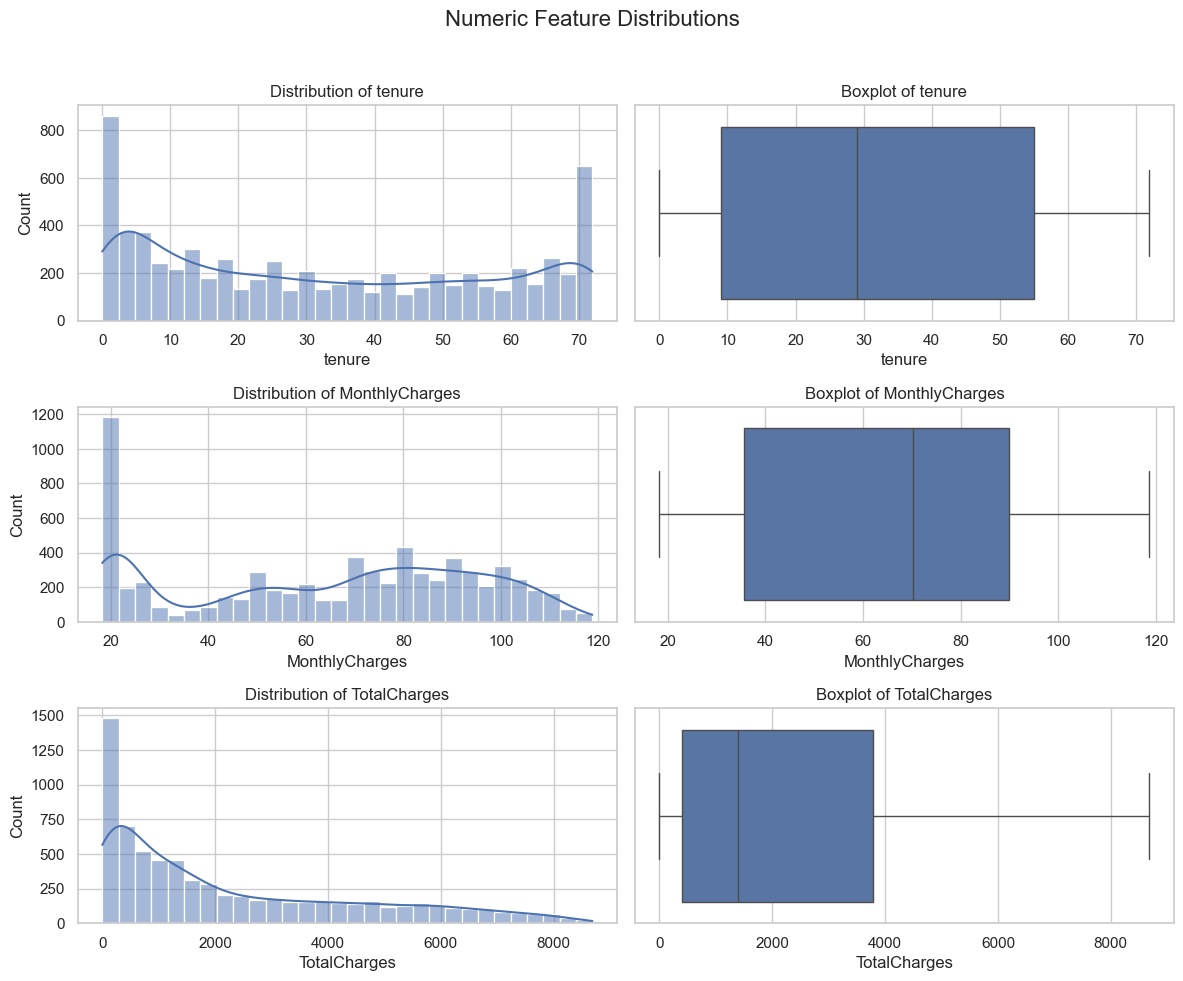

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/numeric_feature_distributions.png')

In [25]:
# Numeric distribution figure: one row per numeric feature, with histogram and
# boxplot next to each other.
n_numeric = len(numeric_columns_inspect)

fig, axes = plt.subplots(
    nrows=n_numeric,
    ncols=2,
    figsize=(12, 3.2 * n_numeric),
)

if n_numeric == 1:
    axes = np.array([axes])

for row_index, column in enumerate(numeric_columns_inspect):
    hist_ax = axes[row_index, 0]
    box_ax = axes[row_index, 1]

    sns.histplot(
        data=df_inspect,
        x=column,
        bins=30,
        kde=True,
        ax=hist_ax,
    )
    hist_ax.set_title(f"Distribution of {column}")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Count")

    sns.boxplot(
        data=df_inspect,
        x=column,
        ax=box_ax,
    )
    box_ax.set_title(f"Boxplot of {column}")
    box_ax.set_xlabel(column)

fig.suptitle("Numeric Feature Distributions", fontsize=16, y=1.02)
fig.tight_layout()

numeric_distribution_path = FIGURES_DIR / "numeric_feature_distributions.png"
fig.savefig(numeric_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_distribution_path

In [26]:
# Numeric correlation matrix, including Churn encoded as 0/1.
#
# This is a compact diagnostic for linear association. It should not be
# interpreted as a full feature-selection method, because nonlinear
# relationships and categorical effects are not captured by ordinary Pearson
# correlation.
numeric_correlation_columns = numeric_columns_inspect + ["Churn_binary"]

numeric_correlation_matrix = df_inspect[numeric_correlation_columns].corr()

numeric_correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_binary
tenure,1.0000,0.2479,0.8262,-0.3522
MonthlyCharges,0.2479,1.0000,0.6512,0.1934
TotalCharges,0.8262,0.6512,1.0000,-0.1983
Churn_binary,-0.3522,0.1934,-0.1983,1.0000


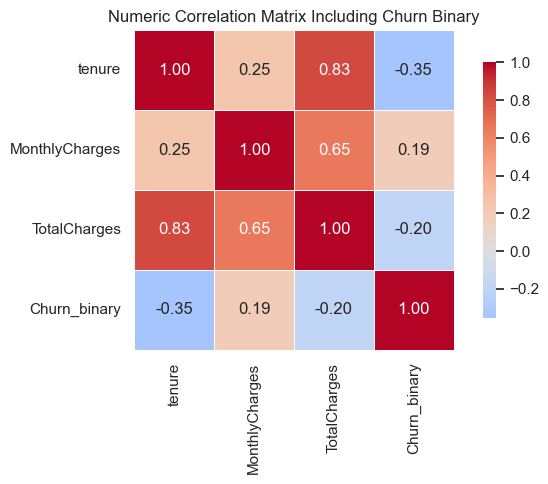

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/numeric_correlation_matrix.png')

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    numeric_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Numeric Correlation Matrix Including Churn Binary")
fig.tight_layout()

numeric_correlation_path = FIGURES_DIR / "numeric_correlation_matrix.png"
fig.savefig(numeric_correlation_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_correlation_path

In [28]:
# Categorical feature columns for distribution and churn-rate inspection.
# Exclude the identifier and the target itself.
categorical_feature_columns_inspect = [
    column
    for column in categorical_columns_inspect
    if column not in [IDENTIFIER_COLUMN, TARGET_COLUMN]
]

categorical_feature_columns_inspect

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

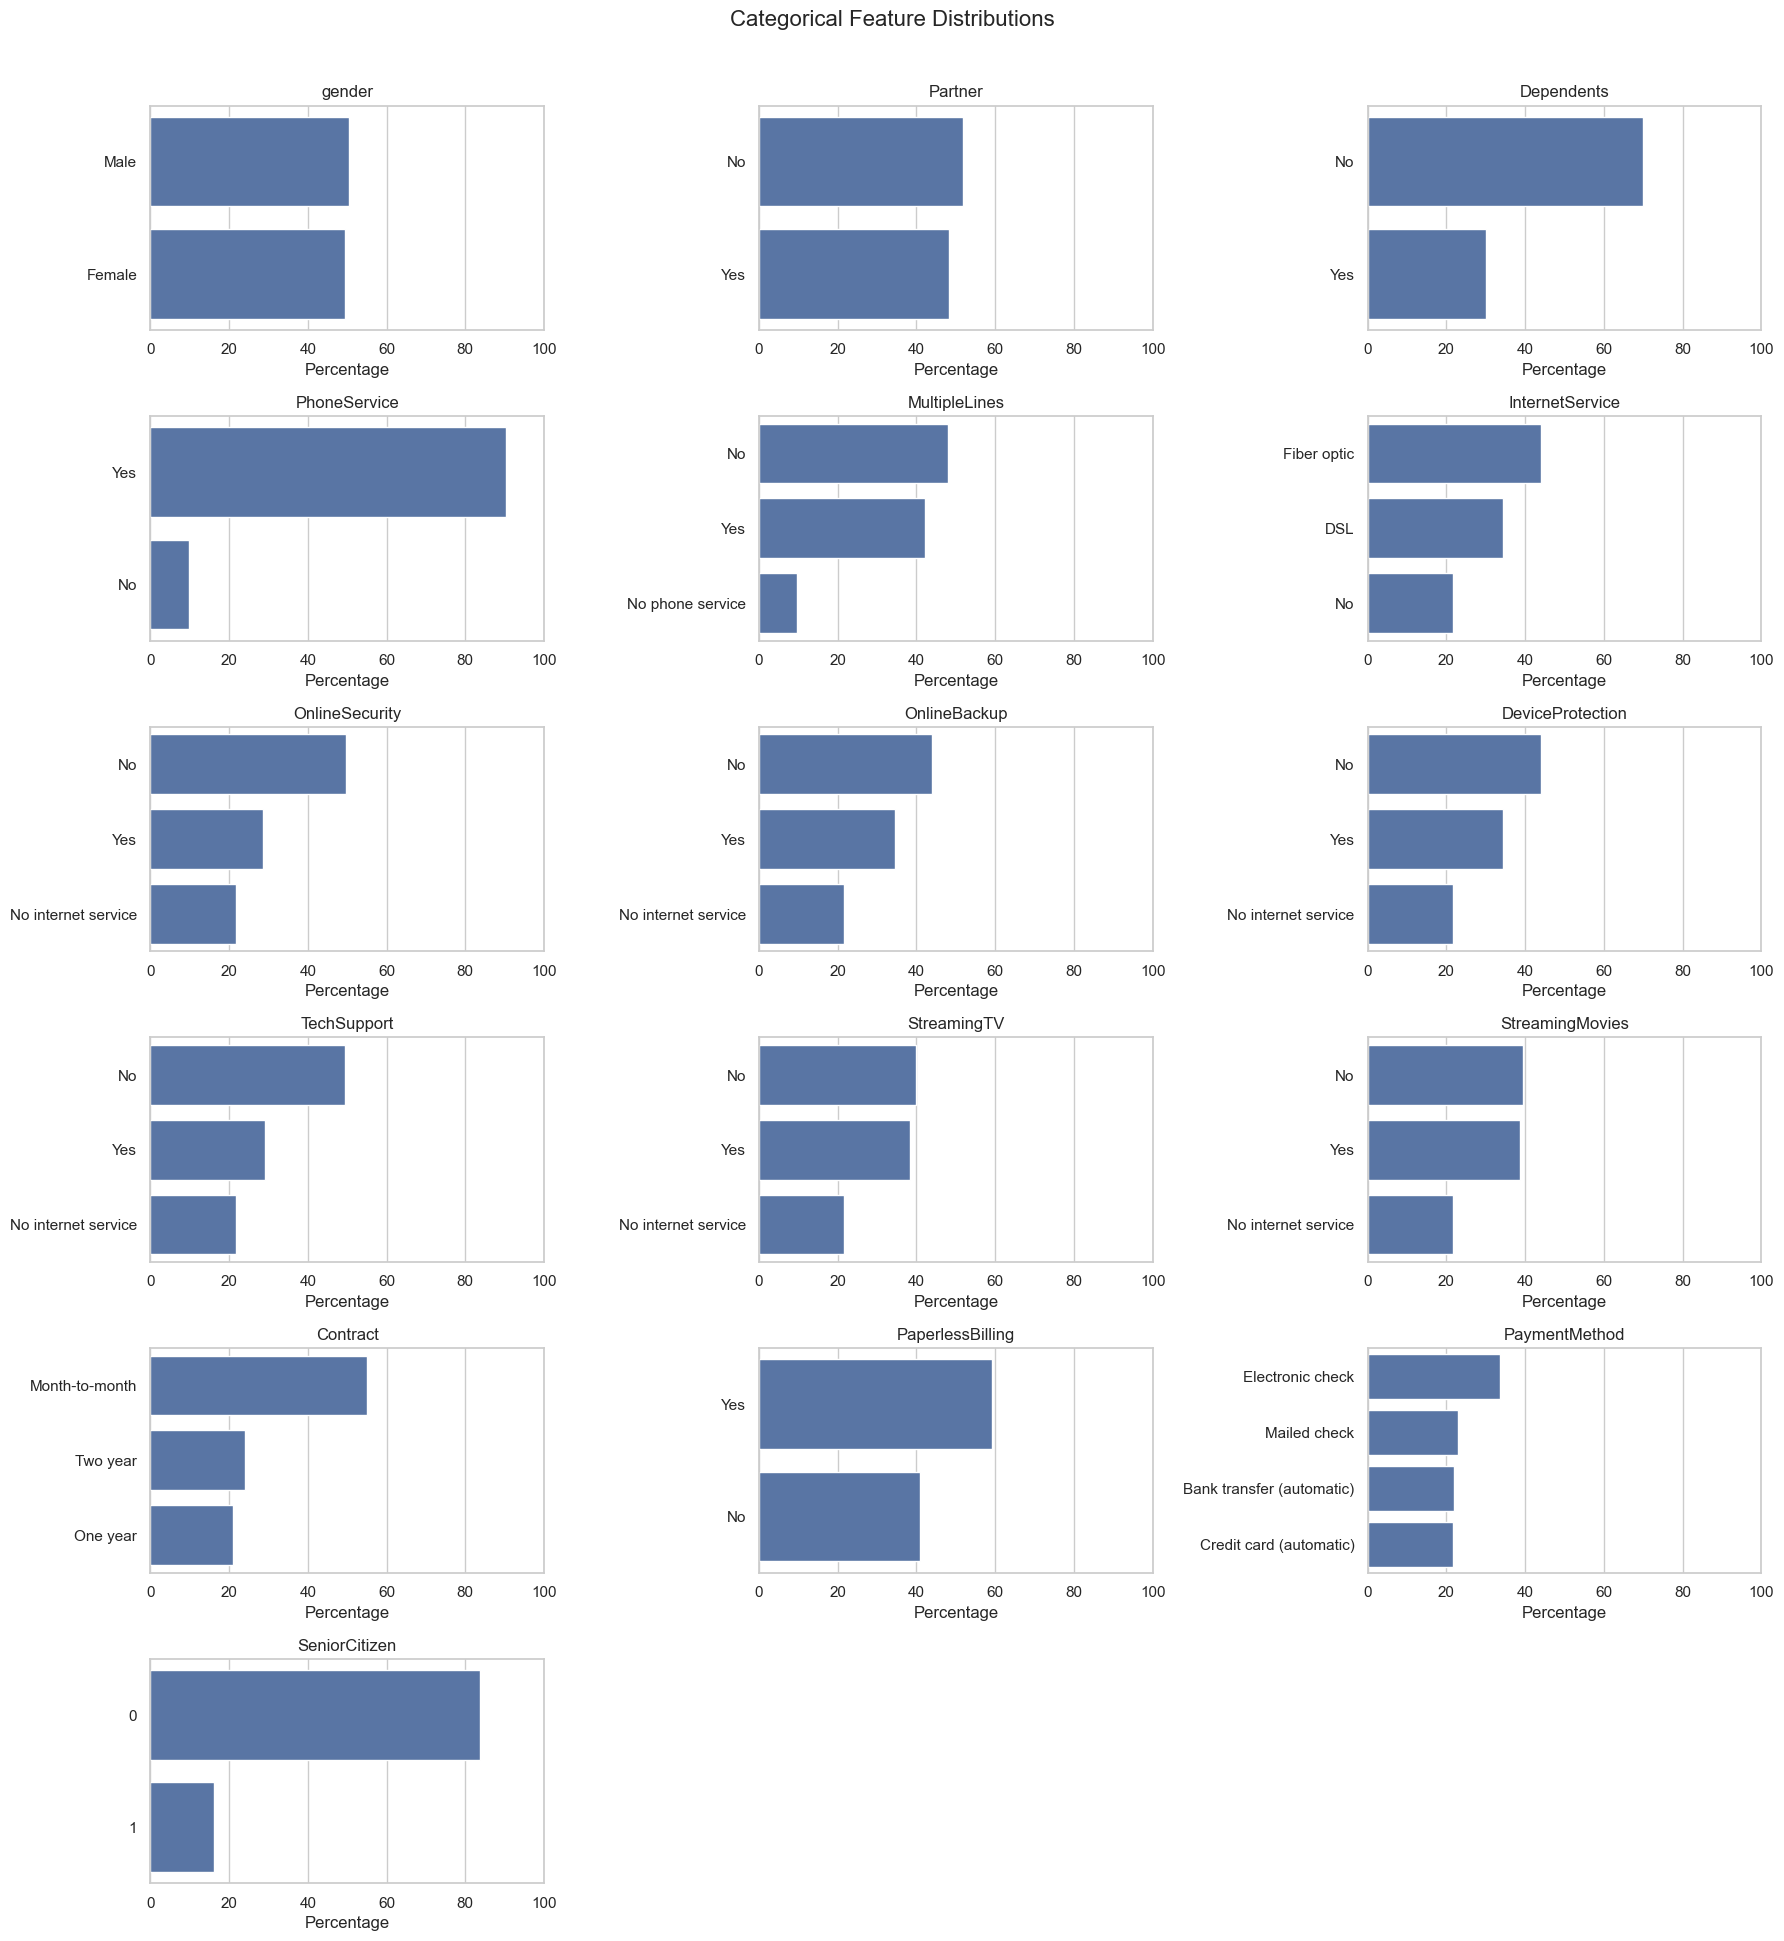

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/categorical_feature_frequencies.png')

In [29]:
# Compact categorical frequency plot grid.
#
# A categorical variable does not have a histogram in the same sense as a
# numeric variable. The categorical equivalent is a count/frequency bar plot.
# Horizontal bars are used because several category labels are relatively long.
n_categorical = len(categorical_feature_columns_inspect)
n_cols = 3
n_rows = int(np.ceil(n_categorical / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 3.2 * n_rows),
)

axes = axes.flatten()

for ax, column in zip(axes, categorical_feature_columns_inspect):
    frequency_table = (
        df_inspect[column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .rename("percentage")
        .reset_index()
    )

    frequency_table.columns = ["level", "percentage"]
    frequency_table["level"] = frequency_table["level"].astype(str)

    sns.barplot(
        data=frequency_table,
        x="percentage",
        y="level",
        ax=ax,
    )

    ax.set_title(column)
    ax.set_xlabel("Percentage")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

for unused_ax in axes[n_categorical:]:
    unused_ax.remove()

fig.suptitle("Categorical Feature Distributions", fontsize=16, y=1.01)
fig.tight_layout()

categorical_frequency_path = FIGURES_DIR / "categorical_feature_frequencies.png"
fig.savefig(categorical_frequency_path, dpi=300, bbox_inches="tight")

plt.show()

categorical_frequency_path

In [30]:
# Compact categorical churn-rate table.
#
# This table replaces many separate feature-target outputs. It summarizes, for
# each categorical feature level:
# - how many observations are in the level
# - how common the level is in the dataset
# - how many churn cases occur in the level
# - the churn percentage within the level
categorical_churn_tables = []

for column in categorical_feature_columns_inspect:
    table = (
        df_inspect.groupby(column, dropna=False)
        .agg(
            count=(TARGET_COLUMN, "size"),
            churn_count=(TARGET_COLUMN, lambda values: (values == POSITIVE_CLASS).sum()),
        )
        .reset_index()
        .rename(columns={column: "level"})
    )

    table["level"] = table["level"].astype(str)

    table.insert(0, "feature", column)
    table["dataset_percentage"] = 100 * table["count"] / len(df_inspect)
    table["churn_percentage"] = 100 * table["churn_count"] / table["count"]

    categorical_churn_tables.append(table)

categorical_churn_summary = pd.concat(
    categorical_churn_tables,
    ignore_index=True,
)

categorical_churn_summary = categorical_churn_summary[
    [
        "feature",
        "level",
        "count",
        "dataset_percentage",
        "churn_count",
        "churn_percentage",
    ]
].sort_values(
    ["feature", "churn_percentage"],
    ascending=[True, False],
).reset_index(drop=True)

categorical_churn_summary

,feature,level,count,dataset_percentage,churn_count,churn_percentage
0,Contract,Month-to-month,3875,55.0192,1655,42.7097
1,Contract,One year,1473,20.9144,166,11.2695
2,Contract,Two year,1695,24.0664,48,2.8319
3,Dependents,No,4933,70.0412,1543,31.2791
4,Dependents,Yes,2110,29.9588,326,15.4502
5,DeviceProtection,No,3095,43.9443,1211,39.1276
6,DeviceProtection,Yes,2422,34.3888,545,22.5021
7,DeviceProtection,No internet service,1526,21.6669,113,7.4050
8,InternetService,Fiber optic,3096,43.9585,1297,41.8928
9,InternetService,DSL,2421,34.3746,459,18.9591


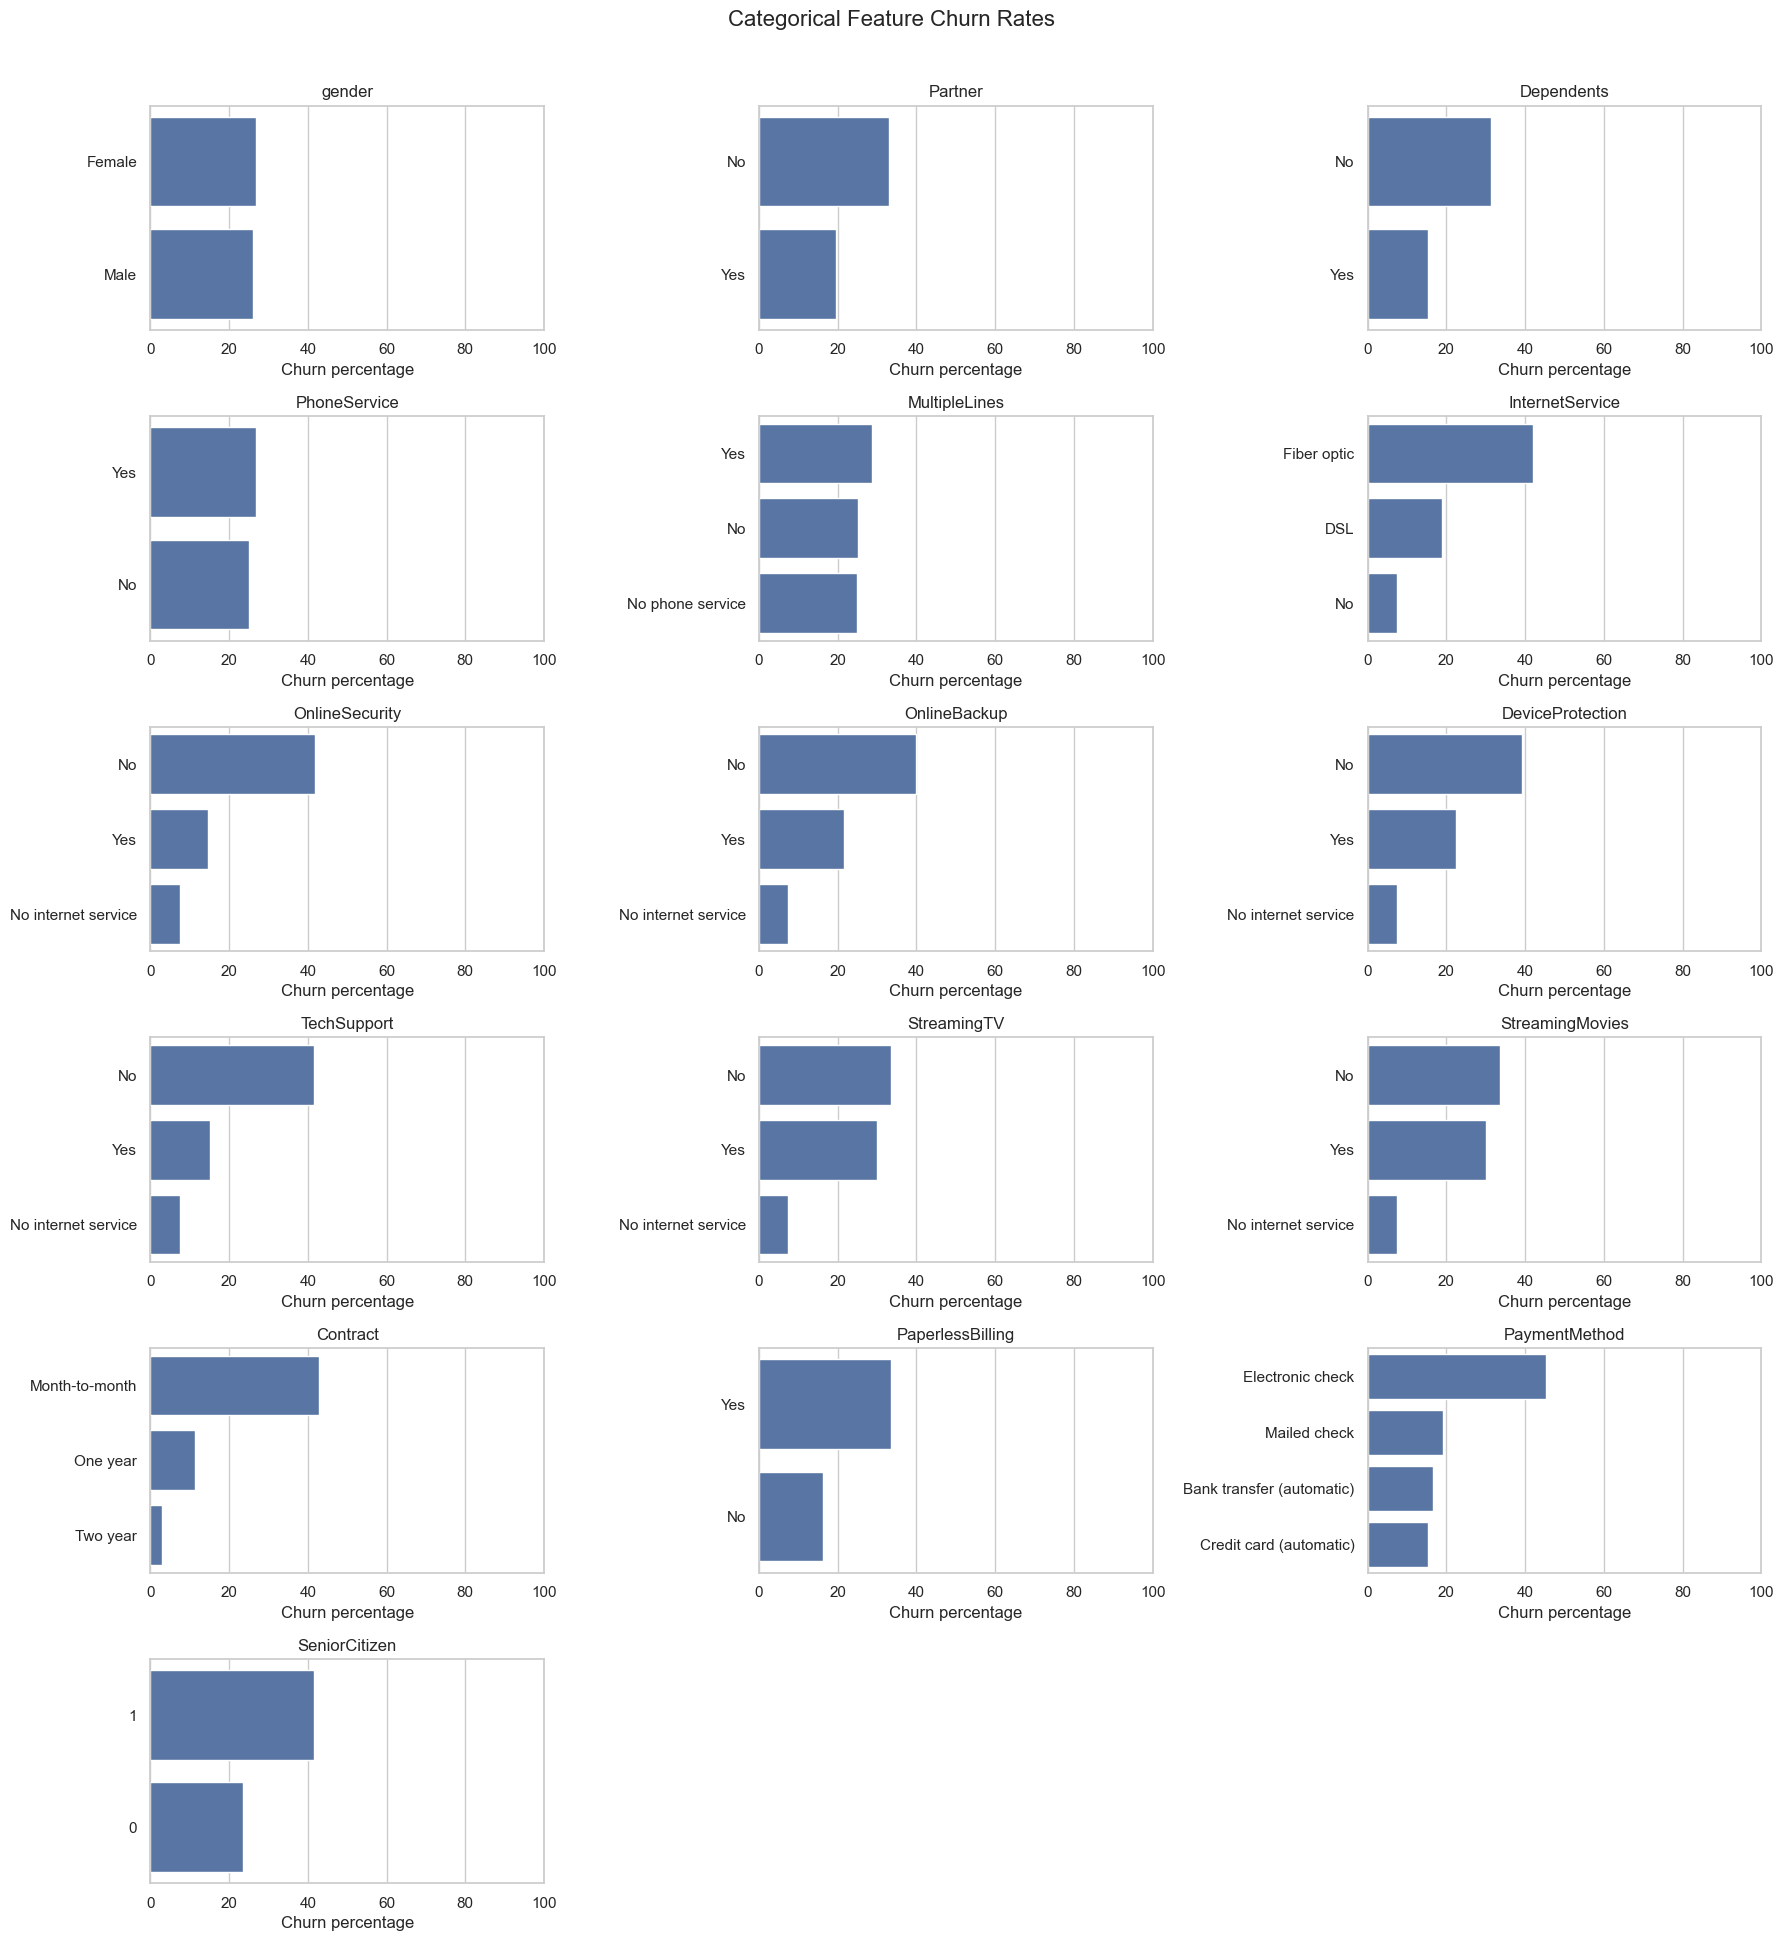

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/categorical_feature_churn_rates.png')

In [31]:
# Compact categorical churn-rate plot grid.
#
# The frequency plot grid shows how common each category level is.
# This churn-rate plot grid shows how often customers churn within each
# category level.
#
# These two figures answer different questions:
# - frequency plot: how common is this level in the dataset?
# - churn-rate plot: how often does churn occur inside this level?
#
# The table categorical_churn_summary contains the exact values. This figure
# provides a compact visual overview for inspection and reporting.

n_categorical = len(categorical_feature_columns_inspect)
n_cols = 3
n_rows = int(np.ceil(n_categorical / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(18, 3.2 * n_rows),
)

axes = axes.flatten()

for ax, column in zip(axes, categorical_feature_columns_inspect):
    plot_table = categorical_churn_summary.loc[
        categorical_churn_summary["feature"] == column,
        ["level", "count", "churn_percentage"],
    ].copy()

    plot_table["level"] = plot_table["level"].astype(str)

    plot_table = plot_table.sort_values(
        "churn_percentage",
        ascending=False,
    )

    sns.barplot(
        data=plot_table,
        x="churn_percentage",
        y="level",
        ax=ax,
    )

    ax.set_title(column)
    ax.set_xlabel("Churn percentage")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

for unused_ax in axes[n_categorical:]:
    unused_ax.remove()

fig.suptitle("Categorical Feature Churn Rates", fontsize=16, y=1.01)
fig.tight_layout()

categorical_churn_rate_path = FIGURES_DIR / "categorical_feature_churn_rates.png"
fig.savefig(categorical_churn_rate_path, dpi=300, bbox_inches="tight")

plt.show()

categorical_churn_rate_path

In [32]:
# ---------------------------------------------------------------------------
# Save corrected interim dataset
# ---------------------------------------------------------------------------
#
# The interim dataset contains the confirmed correction from the raw data audit:
# - TotalCharges is converted from string to numeric.
# - Blank TotalCharges values for tenure-zero customers are set to 0.0.
#
# This file is saved locally for the next workflow stages. It is not committed
# to Git because data/interim/ is ignored.

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

INTERIM_DATA_PATH = INTERIM_DATA_DIR / "telco_churn_interim.csv"

df_inspect.to_csv(INTERIM_DATA_PATH, index=False)

pd.DataFrame(
    {
        "item": [
            "interim_data_path",
            "number_of_rows",
            "number_of_columns",
            "total_missing_values",
        ],
        "value": [
            str(INTERIM_DATA_PATH),
            df_inspect.shape[0],
            df_inspect.shape[1],
            int(df_inspect.isna().sum().sum()),
        ],
    }
)

,item,value
0,interim_data_path,C:\Projects_Data\classification\telco-customer...
1,number_of_rows,7043
2,number_of_columns,22
3,total_missing_values,0
